# Café counts and candidate areas in central Moscow

**Applied Data Science Capstone (IBM / Coursera).** Historical registers of 2019 and an
OpenStreetMap snapshot of 2026 are compared on 364 candidate areas. This notebook predicts
recorded café and restaurant counts from their surroundings and produces a fieldwork shortlist.
It does not observe consumer demand, pedestrian traffic, rents, available premises or profitability.

The statistical corrections and their regression tests live in `src/moscow_cafes/model.py` and
`tests/test_model.py`. Run all cells in order, or use `python scripts/run_analysis.py` from the
repository root; the committed snapshots allow offline execution.

## 1. Question and interpretation

Where are there fewer recorded cafés and restaurants than a count model predicts from the
observed surroundings? Such areas may be useful starting points for site visits.

A negative residual is not evidence of unmet consumer demand. Missing venues, high rents,
inaccessible streets, absent premises and omitted characteristics can produce the same pattern.
The model estimates a conditional count association, not the effect of opening a shop or station.

We also contrast the 2019 register with OpenStreetMap 2026. This is an exploratory comparison
between different sources, not a like-for-like measure of openings and closures or a validated
forecast made in 2019. Both the historical and current shortlists are computed retrospectively.

## 2. Data

| Layer | Source | Used as |
|---|---|---|
| Candidate locations | Hexagonal grid within 6 km of Red Square, 600 m step (notebook 01); addresses from the Yandex Geocoder | units of analysis |
| Catering register | [data.mos.ru](https://data.mos.ru), 2019: 15,366 venues with type, seats and a chain flag | competitors (*кафе* and *ресторан*) and the rest of the catering scene |
| Metro entrances and exits | data.mos.ru, 2019 | infrastructure proxy: exits within 300 m, distance to the nearest exit |
| Surface transport stops | data.mos.ru, 2019 | infrastructure proxy: stops within 300 m |
| Paid street parking | data.mos.ru, 2019 | accessibility by car: parking spaces within 300 m |
| Shopping register | data.mos.ru, 2019: 60,320 shops | infrastructure proxy: shops within 300 m |
| Consumer services | data.mos.ru, 2019 | infrastructure proxy: hairdressers, dry cleaners, repairs... within 300 m |
| Fitness | data.mos.ru, 2019 | infrastructure proxy: gyms within 300 m |
| Universities and colleges | [OpenStreetMap](https://www.openstreetmap.org/copyright), 2026 | 2026 count model only; no observed student flow |
| Cafés and restaurants | OpenStreetMap, 2026 | exploratory source comparison in section 8 |
| Surrounding-object layers | OpenStreetMap, 2026: metro, MCC and MCD entrances, stops, shops, services, gyms | the 2026 shortlist of section 9 |

Notes on the data:

* The catering and shopping registers were restored in 2026 from a backup of the 2019 Dropbox
  (`data/dropbox_2019/`). As in notebook 01, **competitors are the *кафе* and *ресторан* types of
  the catering register**; fast food, bars, canteens and buffets are described but not counted.
* The education register of 2019 (`EducationUTF.txt`, 620 organisations run by the city
  education department) holds mostly schools, 534 of them, and no federal universities, so
  universities and colleges come from OpenStreetMap. The 2026 education layer is excluded from the 2019 count model and typology to avoid using future information; it is used in the 2026 model only.
* The fitness register lists gym halls, several per club; they are merged into 385 facilities.
  It covers mostly municipal sports centres.
* The cinema register holds only 14 municipal cinemas, too few to describe 364 cells, so it is
  not used.

In [1]:
import json
import sys
from html import escape
from pathlib import Path

import branca.colormap as bcm
import folium
import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from folium.plugins import HeatMap
from matplotlib.collections import PolyCollection
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from moscow_cafes import data  # noqa: E402
from moscow_cafes import model as modelling  # noqa: E402
from moscow_cafes.features import RADIUS_M, build_features  # noqa: E402
from moscow_cafes.geo import (  # noqa: E402
    RED_SQUARE,
    count_within,
    distance_from,
    grid_hexagons,
    nearest,
    to_xy,
    xy_array,
)

REPORT = ROOT / "report"
FIGURES = REPORT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 2)

In [2]:
# Chart styling: a light surface, hairline axes, and one colour job per chart:
# sequential blue for magnitude, red <-> gray <-> blue for "fewer / more than expected".
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, RED, NEUTRAL = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#f0efec"
BLUE_STEPS = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("fewer_more", [RED, NEUTRAL, BLUE])
HALO = [patheffects.withStroke(linewidth=3, foreground=SURFACE)]  # keeps labels legible over map tiles

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "font.size": 10,
        "legend.frameon": False,
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png")

### Loading the layers

In [3]:
cells = data.load_candidates()
layers = {
    "catering": data.load_catering(),
    "metro": data.load_metro_exits(),
    "bus": data.load_bus_stops(),
    "parking": data.load_parking(),
    "shops": data.load_shops(),
    "services": data.load_services(),
    "fitness": data.load_fitness(),
    "education": data.load_education(),
}
osm_catering = data.load_osm_catering()
osm_meta = json.loads((ROOT / "data" / "osm" / "osm_meta.json").read_text(encoding="utf-8"))
osm_date = osm_meta["catering"]["timestamp_osm_base"][:10]

pd.DataFrame(
    [
        ("Candidate locations", len(cells), "grid of notebook 01", "2019"),
        ("Catering venues", len(layers["catering"]), "data.mos.ru, whole city", "2019"),
        ("Metro entrances and exits", len(layers["metro"]), "data.mos.ru, whole city", "2019"),
        ("Surface transport stops", len(layers["bus"]), "data.mos.ru, whole city", "2019"),
        ("Paid parking zones", len(layers["parking"]), "data.mos.ru, whole city", "2019"),
        ("Shops", len(layers["shops"]), "data.mos.ru, whole city", "2019"),
        ("Consumer services", len(layers["services"]), "data.mos.ru, whole city", "2019"),
        ("Fitness facilities", len(layers["fitness"]), "data.mos.ru, whole city", "2019"),
        ("Universities and colleges", len(layers["education"]), "OpenStreetMap, 7 km around Red Square", osm_date),
        ("Catering venues (sections 8-9)", len(osm_catering), "OpenStreetMap, 7 km around Red Square", osm_date),
        ("Footfall generators (section 9)", len(pd.read_csv(ROOT / "data" / "osm" / "osm_demand.csv")),
         "OpenStreetMap, 7 km around Red Square", osm_meta["demand"]["retrieved"]),
    ],
    columns=["Layer", "Records", "Coverage", "Vintage"],
)

,Layer,Records,Coverage,Vintage
0,Candidate locations,364,grid of notebook 01,2019
1,Catering venues,15366,"data.mos.ru, whole city",2019
2,Metro entrances and exits,1067,"data.mos.ru, whole city",2019
3,Surface transport stops,11507,"data.mos.ru, whole city",2019
4,Paid parking zones,9254,"data.mos.ru, whole city",2019
5,Shops,60320,"data.mos.ru, whole city",2019
6,Consumer services,14540,"data.mos.ru, whole city",2019
7,Fitness facilities,385,"data.mos.ru, whole city",2019
8,Universities and colleges,283,"OpenStreetMap, 7 km around Red Square",2026-09-28
9,Catering venues (sections 8-9),6729,"OpenStreetMap, 7 km around Red Square",2026-09-28


## 3. Method

1. Project WGS84 coordinates to UTM 37N. Distances and circular catchments are **straight-line**,
   not walking routes or five-minute isochrones.
2. Count each source layer within 250, 300 and 400 m. Parking contributes recorded capacity.
   A café and a restaurant each contribute one venue; fast food is a sensitivity variant.
3. Describe associations with Spearman correlations and an exploratory k-means typology (k=4).
4. Predict counts using a Poisson GLM with capped `log1p` counts and linear distances in km.
   The 2019 model excludes education measured in 2026. Caps and scaling are fitted on training
   rows only. The penalty is chosen by an inner spatial CV, separately inside every outer fold.
5. Hold out 2×2 km blocks in six folds; also exclude training centres within 800 m of any test
   centre, both in inner and outer validation. This prevents overlap of the largest 400 m
   catchments, but does not guarantee the absence of longer-range spatial dependence.
6. Repeat this nested validation over 50 block assignments (seeds 0–49). Average the out-of-fold
   predictions within each radius, compute NB2-scaled residuals, and average the three scores.
   The radii are correlated, not independent replications; scores are not normal z statistics.
7. In each repeat, screen for a station entrance within 500 m, at least 10 shops plus services,
   and a prediction at or above the grid median, at two or more radii. The final shortlist also
   requires this screening rule in at least 80% of repeats and a negative aggregate score.
   The 80% cutoff is an explicit screening policy, not a significance or success probability.
   Rank unrounded scores and publish split sensitivity for every cell.
8. Contrast the two source snapshots without interpreting the difference as verified market
   growth. Baseline-adjusted regressions describe associations in `log(count + 1)` only.

In [4]:
features = build_features(cells, **layers)

# Distances from Red Square as stored by notebook 01 (UTM zone 33) versus zone 37.
legacy = pd.read_csv(ROOT / "data" / "mos_open_data" / "df_locations.csv", index_col=0)["Distance from center"]
stretch = (legacy / features["center_distance"]).mean() - 1
print(f"UTM zone 33 overstated distances by {stretch:.1%}: the farthest cell is "
      f"{legacy.max():,.0f} m away in zone 33 and {features['center_distance'].max():,.0f} m in reality.")

features.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

UTM zone 33 overstated distances by 2.4%: the farthest cell is 5,992 m away in zone 33 and 5,851 m in reality.


,mean,std,min,25%,50%,75%,max
cafes,6.98,9.47,0.0,1.00,3.00,9.00,53.00
restaurants,3.07,4.82,0.0,0.00,1.00,4.00,31.00
competitors,10.05,13.13,0.0,2.00,5.00,13.00,79.00
fast_food,1.16,2.65,0.0,0.00,0.00,1.00,21.00
bars,1.16,2.31,0.0,0.00,0.00,1.00,15.00
metro_exits,0.74,1.99,0.0,0.00,0.00,0.00,15.00
metro_distance,570.96,316.66,3.6,334.18,545.12,763.02,1648.36
bus_stops,4.18,2.97,0.0,2.00,4.00,6.00,17.00
parking_spaces,131.87,107.81,0.0,39.00,121.50,191.50,510.00
shops,31.20,84.96,0.0,4.00,11.50,26.00,1316.00


## 4. Exploratory analysis

### The catering scene

In [5]:
catering = layers["catering"]
central = catering[distance_from(catering, *RED_SQUARE) <= 6000]
composition = central.groupby(["type", "amenity"]).size().rename("venues").reset_index("amenity")
composition = composition.sort_values("venues", ascending=False)
composition["share, %"] = (100 * composition["venues"] / composition["venues"].sum()).round(1)

competitors = central[central["is_competitor"]]
chain_counts = competitors.loc[competitors["is_chain"], "chain"].value_counts()
print(f"Within 6 km of Red Square: {len(central):,} catering venues, of which {len(competitors):,} "
      f"cafés and restaurants (the competitors) with {competitors['seats'].sum():,.0f} seats.")
print(f"{competitors['is_chain'].mean():.0%} of the cafés and restaurants belong to chains.")
composition

Within 6 km of Red Square: 5,784 catering venues, of which 3,956 cafés and restaurants (the competitors) with 233,174 seats.
22% of the cafés and restaurants belong to chains.


,amenity,venues,"share, %"
type,,,
кафе,cafe,2747,47.5
ресторан,restaurant,1209,20.9
столовая,other,547,9.5
бар,bar,450,7.8
предприятие быстрого обслуживания,fast_food,377,6.5
буфет,other,201,3.5
кафетерий,other,130,2.2
закусочная,fast_food,71,1.2
магазин (отдел кулинарии),other,52,0.9


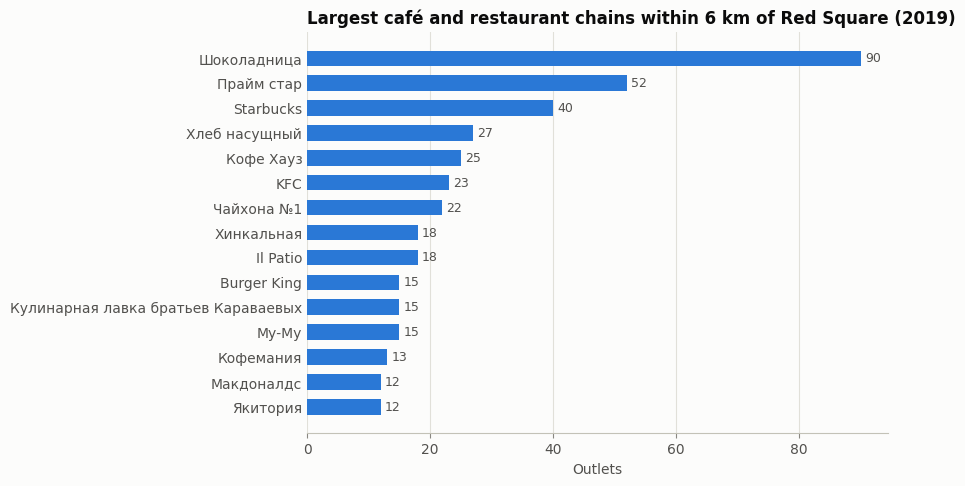

In [6]:
top_chains = chain_counts.head(15).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.barh(top_chains.index, top_chains.values, color=BLUE, height=0.62)
ax.bar_label(bars, padding=3, color=INK_2, fontsize=9)
ax.set_title("Largest café and restaurant chains within 6 km of Red Square (2019)")
ax.set_xlabel("Outlets")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig1_top_chains")
plt.show()

Chain names are normalised with the rules of the 2019 cleaning script. Шоколадница leads by far,
followed by Prime (*Прайм стар*), Starbucks, Хлеб насущный and Кофе Хауз, with KFC as the first
fast-food chain registered as a café. Chains run only about a fifth of the cafés and restaurants:
the market is mostly independent venues.

### Where the competitors are

The candidate cells are drawn as the hexagons of the grid; the static maps use kilometres from
Red Square as coordinates.

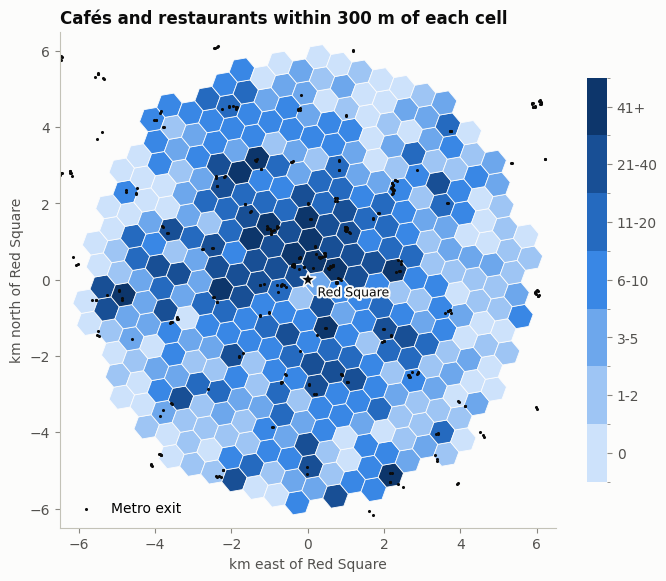

In [7]:
HEX_LATLON = grid_hexagons(cells["lat"], cells["lon"])
hex_x, hex_y = to_xy(HEX_LATLON[..., 0], HEX_LATLON[..., 1])
center_x, center_y = to_xy(*RED_SQUARE)
HEX_KM = np.stack([(hex_x - center_x) / 1000, (hex_y - center_y) / 1000], axis=-1)
CELL_KM = HEX_KM.mean(axis=1)
EXTENT_KM = 6.5


def hex_map(ax, values, cmap, norm, title, **collection_kwargs):
    """Draw the grid as a choropleth of `values` (one per cell, in cell order)."""
    tiles = PolyCollection(
        HEX_KM, array=np.asarray(values, dtype=float), cmap=cmap, norm=norm,
        edgecolor=SURFACE, linewidth=0.6, **collection_kwargs,
    )
    ax.add_collection(tiles)
    ax.set_xlim(-EXTENT_KM, EXTENT_KM)
    ax.set_ylim(-EXTENT_KM, EXTENT_KM)
    ax.set_aspect("equal")
    ax.plot(0, 0, marker="*", markersize=12, color=INK, markeredgecolor=SURFACE, markeredgewidth=1.2)
    ax.annotate("Red Square", (0, 0), xytext=(7, -12), textcoords="offset points", color=INK, fontsize=9,
                path_effects=HALO)
    ax.set_xlabel("km east of Red Square")
    ax.set_ylabel("km north of Red Square")
    ax.set_title(title)
    return tiles


metro = layers["metro"]
metro_xy = xy_array(metro)
metro_km = (metro_xy - [center_x, center_y]) / 1000
metro_km = metro_km[np.abs(metro_km).max(axis=1) < EXTENT_KM]

bins = [0, 1, 3, 6, 11, 21, 41, 1000]
fig, ax = plt.subplots(figsize=(8, 7))
tiles = hex_map(ax, features["competitors"], ListedColormap(BLUE_STEPS), BoundaryNorm(bins, len(BLUE_STEPS)),
                "Cafés and restaurants within 300 m of each cell")
ax.scatter(*metro_km.T, s=5, color=INK, linewidths=0, label="Metro exit")
colorbar = fig.colorbar(tiles, ax=ax, shrink=0.75, ticks=[0.5, 2, 4.5, 8.5, 16, 31, 520])
colorbar.ax.set_yticklabels(["0", "1-2", "3-5", "6-10", "11-20", "21-40", "41+"])
colorbar.outline.set_visible(False)
ax.legend(loc="lower left")
save(fig, "fig2_competitors_map")
plt.show()

The same picture on an interactive map: the heat map shows the competitors, the grey hexagons are
the candidate cells, the dots are metro exits. (GitHub does not render these maps; open the
notebook in [nbviewer](https://nbviewer.org/github/petro1eum/capstone/blob/master/notebooks/03_cafe_location_analysis.ipynb)
or run it locally.)

In [8]:
def base_map():
    fmap = folium.Map(location=RED_SQUARE, zoom_start=12, tiles="OpenStreetMap", control_scale=True)
    folium.Marker(RED_SQUARE, tooltip="Red Square", icon=folium.Icon(color="gray", icon="star")).add_to(fmap)
    return fmap


def hex_layer(table, fill, tooltip_fields, tooltip_aliases, name, opacity=0.6, show=True):
    """GeoJSON layer of the grid hexagons; `table` is indexed by cell, `fill` holds hex colours."""
    records = json.loads(table[tooltip_fields].to_json(orient="records", force_ascii=False))
    features_geojson = []
    for cell_id, record in zip(table.index, records, strict=True):
        ring = [[lon, lat] for lat, lon in HEX_LATLON[cells.index.get_loc(cell_id)]]
        features_geojson.append({
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [ring + [ring[0]]]},
            "properties": {**{k: escape(v) if isinstance(v, str) else v for k, v in record.items()},
                           "fill": fill.loc[cell_id]},
        })
    return folium.GeoJson(
        {"type": "FeatureCollection", "features": features_geojson},
        name=name,
        show=show,
        style_function=lambda f: {"fillColor": f["properties"]["fill"], "fillOpacity": opacity,
                                  "color": SURFACE, "weight": 0.8},
        highlight_function=lambda f: {"weight": 2.5, "color": INK},
        tooltip=folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases, sticky=True),
    )


overview = cells[["address"]].join(features[["competitors", "metro_exits", "shops", "services"]])
grid_map = base_map()
hex_layer(overview, pd.Series(NEUTRAL, index=overview.index), list(overview.columns),
          ["Address", "Cafés and restaurants", "Metro exits", "Shops", "Services"], "Candidate cells",
          opacity=0.3).add_to(grid_map)
HeatMap(competitors[["lat", "lon"]].to_numpy().tolist(), name="Competitors", radius=12, blur=15,
        min_opacity=0.25).add_to(grid_map)
central_metro = metro[distance_from(metro, *RED_SQUARE) <= 6500]
metro_layer = folium.FeatureGroup(name="Metro exits")
for _, exit_ in central_metro.iterrows():
    folium.CircleMarker([exit_["lat"], exit_["lon"]], radius=2, color=INK, weight=1, fill=True,
                        fill_opacity=1, tooltip=exit_["name"]).add_to(metro_layer)
metro_layer.add_to(grid_map)
folium.LayerControl(collapsed=False).add_to(grid_map)
grid_map

Competitors crowd inside the Garden Ring and along the radial streets, and thin out towards the
Third Ring Road, apart from hot spots around big transport hubs. Which footfall generators go
together with them?

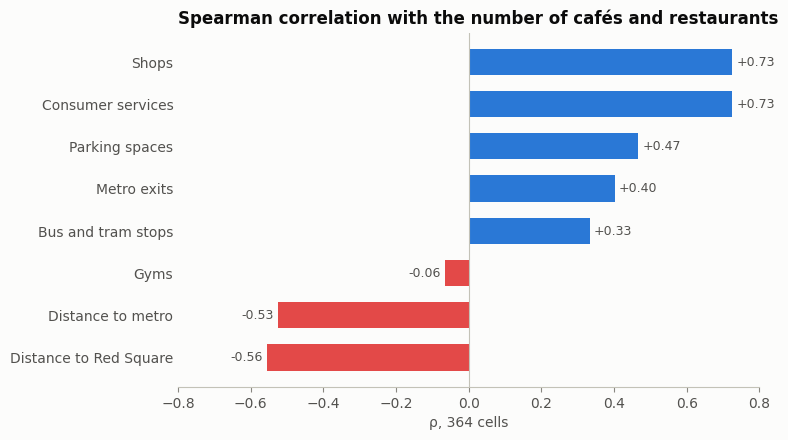

,Spearman ρ
Distance to Red Square,-0.56
Distance to metro,-0.53
Gyms,-0.06
Bus and tram stops,0.33
Metro exits,0.40
Parking spaces,0.47
Consumer services,0.73
Shops,0.73


In [9]:
drivers = ["metro_exits", "metro_distance", "bus_stops", "parking_spaces", "shops", "services",
           "fitness", "center_distance"]
labels = {
    "metro_exits": "Metro exits", "metro_distance": "Distance to metro", "bus_stops": "Bus and tram stops",
    "parking_spaces": "Parking spaces", "shops": "Shops", "services": "Consumer services", "fitness": "Gyms",
    "education": "Universities and colleges", "center_distance": "Distance to Red Square",
}
rho = features[drivers].corrwith(features["competitors"], method="spearman").sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.barh([labels[d] for d in rho.index], rho.values, color=[BLUE if v > 0 else RED for v in rho.values],
               height=0.62)
ax.bar_label(bars, fmt="%+.2f", padding=3, color=INK_2, fontsize=9)
ax.axvline(0, color=AXIS, linewidth=0.8)
ax.set_xlim(-0.8, 0.8)
ax.set_title("Spearman correlation with the number of cafés and restaurants")
ax.set_xlabel("ρ, 364 cells")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig3_correlations")
plt.show()
rho.rename(index=labels).to_frame("Spearman ρ")

Competitors go together with consumer services, shops and parking (all mark streets with
ground-floor commerce), and they fall with the distance to the metro and to Red Square. Bus stops have a weaker marginal association; the municipal gyms of the fitness register sit in residential areas
and show little marginal association in this sample; this does not establish no effect.

## 5. Neighbourhood typology

k-means on the standardised features (counts log-transformed, distances in km). The silhouette
score is low for every k, which is normal for a city: urban fabric changes gradually rather than
in separated clumps. k = 2 splits the cells only into "busy" and "quiet", so k = 4, where the
inertia curve bends and the clusters are still easy to name, is used to describe the area.

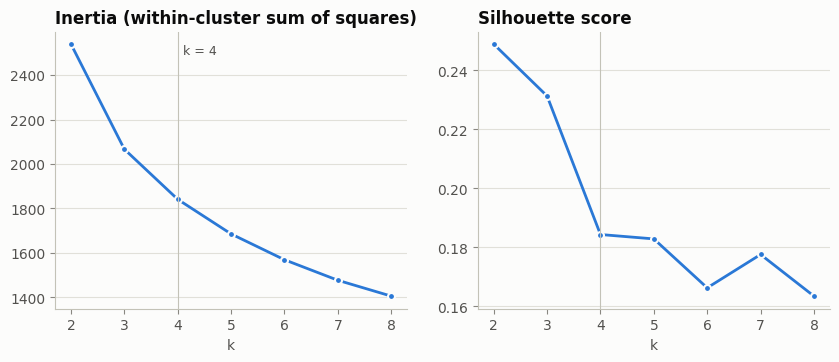

k,2,3,4,5,6,7,8
inertia,2539.75,2066.70,1841.00,1685.24,1569.01,1476.68,1405.33
silhouette,0.25,0.23,0.18,0.18,0.17,0.18,0.16


In [10]:
typology_columns = ["competitors", "fast_food", "bars", "metro_exits", "bus_stops", "parking_spaces",
                    "shops", "services"]
typology_input = np.log1p(features[typology_columns]).assign(
    metro_distance_km=features["metro_distance"] / 1000,
    center_distance_km=features["center_distance"] / 1000,
)
Z = StandardScaler().fit_transform(typology_input)
k_values = list(range(2, 9))
kmeans_fits = {k: KMeans(n_clusters=k, n_init=20, random_state=0).fit(Z) for k in k_values}
k_scores = pd.DataFrame(
    {"inertia": [kmeans_fits[k].inertia_ for k in k_values],
     "silhouette": [silhouette_score(Z, kmeans_fits[k].labels_) for k in k_values]},
    index=pd.Index(k_values, name="k"),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, column, title in zip(
    axes, k_scores.columns, ["Inertia (within-cluster sum of squares)", "Silhouette score"], strict=True
):
    ax.plot(k_scores.index, k_scores[column], color=BLUE, linewidth=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.axvline(4, color=AXIS, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
axes[0].annotate("k = 4", (4, k_scores["inertia"].max()), xytext=(4, 0), textcoords="offset points",
                 color=INK_2, fontsize=9, va="top")
save(fig, "fig4_kmeans_selection")
plt.show()
k_scores.round(3).T

In [11]:
K = 4
cluster_ids = pd.Series(kmeans_fits[K].labels_, index=cells.index)
profile = features.groupby(cluster_ids).median()

# Name the clusters by their profile, so the names do not depend on k-means label numbers.
hubs = profile["metro_exits"].idxmax()
quiet = (profile["shops"] + profile["services"]).idxmin()
central_id, residential_id = sorted(set(profile.index) - {hubs, quiet}, key=lambda c: profile.loc[c, "center_distance"])
CLUSTER_NAMES = {
    hubs: "Transit hubs",
    central_id: "Central neighbourhoods",
    residential_id: "Residential belt",
    quiet: "Parks, rail and industrial land",
}
assert len(set(CLUSTER_NAMES)) == K
CLUSTER_ORDER = ["Transit hubs", "Central neighbourhoods", "Residential belt", "Parks, rail and industrial land"]
CLUSTER_COLORS = dict(zip(CLUSTER_ORDER, [BLUE, ORANGE, AQUA, "#d9d8d2"], strict=True))
cluster = cluster_ids.map(CLUSTER_NAMES)

cluster_profile = features.groupby(cluster).median().reindex(CLUSTER_ORDER)
cluster_profile.insert(0, "cells", cluster.value_counts())
cluster_profile[["cells", "competitors", "fast_food", "bars", "metro_exits", "metro_distance", "bus_stops",
                 "parking_spaces", "shops", "services", "education", "center_distance"]].round(0).astype(int)

,cells,competitors,fast_food,bars,metro_exits,metro_distance,bus_stops,parking_spaces,shops,services,education,center_distance
Transit hubs,50,26,3,2,4,149,6,142,62,16,0,2971
Central neighbourhoods,98,11,0,1,0,463,4,200,18,10,0,2603
Residential belt,141,3,0,0,0,600,4,126,10,4,0,4603
"Parks, rail and industrial land",75,0,0,0,0,849,1,0,1,0,0,5082


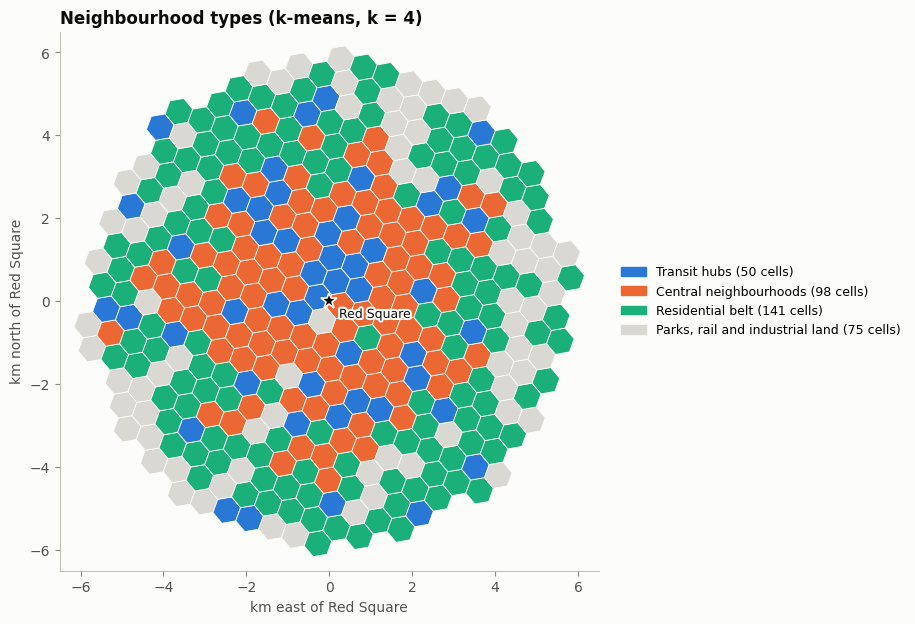

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
cluster_codes = cluster.map({name: i for i, name in enumerate(CLUSTER_ORDER)})
hex_map(ax, cluster_codes, ListedColormap([CLUSTER_COLORS[n] for n in CLUSTER_ORDER]),
        BoundaryNorm(np.arange(-0.5, K), K), "Neighbourhood types (k-means, k = 4)")
ax.legend(handles=[Patch(color=CLUSTER_COLORS[n], label=f"{n} ({(cluster == n).sum()} cells)") for n in CLUSTER_ORDER],
          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
save(fig, "fig5_typology_map")
plt.show()

These are descriptive cluster labels, not verified land-use classifications. The low silhouette
means the groups overlap substantially. Neither a quiet cluster nor a negative count residual
establishes the availability of premises or the suitability of an area for a café.

In [13]:
typology_map = base_map()
typology_table = cells[["address"]].assign(type=cluster).join(
    features[["competitors", "metro_exits", "shops", "services"]])
hex_layer(typology_table, cluster.map(CLUSTER_COLORS), list(typology_table.columns),
          ["Address", "Type", "Cafés and restaurants", "Metro exits", "Shops", "Services"],
          "Neighbourhood types", opacity=0.55).add_to(typology_map)
typology_map

## 6. Count model

The primary specification is an interpretable Poisson GLM with linear distances. Education from
2026 is excluded when fitting 2019. The feature transformer fits 99th-percentile count caps on
each training subset. Hyperparameter selection uses an inner buffered spatial split; reported
outer predictions never use the target values of their held-out blocks. Alternative models below
are diagnostic benchmarks, not a further search whose winning score is reported as unbiased.

In [14]:
COUNT_DRIVERS = [c for c in modelling.COUNT_DRIVERS if c != "education"]
CELL_XY = xy_array(cells)
blocks = modelling.block_ids(CELL_XY)
block_ids = np.unique(blocks)
spatial_cv = modelling.spatial_splits(CELL_XY)
y = features["competitors"]
d2 = modelling.d2
ALPHA = modelling.select_alpha(features, y, CELL_XY, include_education=False)
print(f"{len(block_ids)} spatial blocks; 6 folds; {modelling.BUFFER_M} m buffer; "
      f"full-data descriptive fit alpha={ALPHA}")

38 spatial blocks; 6 folds; 800 m buffer; full-data descriptive fit alpha=0.3


In [15]:
linear_prediction, selected = modelling.nested_predictions(features, y, CELL_XY, include_education=False)
log_prediction, _ = modelling.nested_predictions(features, y, CELL_XY, include_education=False, distances="log1p")
boost_prediction = pd.Series(cross_val_predict(modelling.boosting(include_education=False), features, y,
                                             cv=spatial_cv), index=cells.index)
predictions = {
    "Poisson GLM, linear distances": linear_prediction,
    "Poisson GLM, log1p distances": log_prediction,
    "Gradient boosting, Poisson loss": boost_prediction,
}
model_comparison = pd.Series({name: d2(y, p) for name, p in predictions.items()},
                            name="D², buffered outer CV (seed 0)").to_frame()
model_comparison.round(3)

,"D², buffered outer CV (seed 0)"
"Poisson GLM, linear distances",0.65
"Poisson GLM, log1p distances",0.64
"Gradient boosting, Poisson loss",0.57


The benchmark table uses a single outer split (seed 0); GLMs select alpha inside its training
folds. Final screening below averages 50 nested out-of-fold predictions. D² is the fraction of
Poisson deviance explained, not ordinary R², a success rate, or the fraction of consumer demand
explained. No causal meaning is attached to coefficient signs.

For descriptive model contrasts, fit the primary specification to all cells. Each count is
contrasted from the rounded-up median positive count to twice that count, explicitly shown in
the labels. For `log1p` with cap c the exact ratio is
`exp(beta * (log1p(min(2*x,c)) - log1p(min(x,c))))`.
Block-bootstrap intervals below refit preprocessing, but are conditional on the selected model
and fixed alpha; they are not intervals for business success or for the shortlist ranks.

In [16]:
model = modelling.glm(ALPHA, include_education=False).fit(features, y)
feature_names = list(model.named_steps["design"].get_feature_names_out())
coefficients = pd.Series(model[-1].coef_ / model.named_steps["scale"].scale_, index=feature_names)
count_baselines = {c: max(1, int(np.ceil(features.loc[features[c] > 0, c].median()))) for c in COUNT_DRIVERS}
distance_units = {"metro_distance_km": 0.1, "center_distance_km": 1.0}
effect_labels = {**labels, "metro_distance_km": "Metro exit", "center_distance_km": "Red Square"}


def effects_of(fitted):
    return pd.Series({
        **{c: modelling.count_effect(fitted, c, x, 2*x) for c, x in count_baselines.items()},
        **{c: modelling.distance_effect(fitted, c, delta) for c, delta in distance_units.items()},
    })


rng = np.random.RandomState(0)
bootstrap = []
for _ in range(300):
    rows = np.concatenate([np.flatnonzero(blocks == b) for b in rng.choice(block_ids, size=len(block_ids))])
    fitted = modelling.glm(ALPHA, include_education=False).fit(features.iloc[rows], y.iloc[rows])
    bootstrap.append(effects_of(fitted))
bootstrap = pd.DataFrame(bootstrap)
contrasts = effects_of(model)
effects = pd.DataFrame({
    "change": [f"{effect_labels[c]}: {count_baselines[c]} → {2*count_baselines[c]}"
               if c in count_baselines else f"{effect_labels[c]}: +{1000*distance_units[c]:g} m"
               for c in feature_names],
    "before": [count_baselines.get(c, np.nan) for c in feature_names],
    "after": [2*count_baselines[c] if c in count_baselines else np.nan for c in feature_names],
    "effect, %": contrasts.reindex(feature_names),
    "95% low": bootstrap.quantile(.025).reindex(feature_names),
    "95% high": bootstrap.quantile(.975).reindex(feature_names),
}, index=feature_names).sort_values("effect, %")
effects

,change,before,after,"effect, %",95% low,95% high
center_distance_km,Red Square: +1000 m,NaN,NaN,-23.05,-30.00,-18.03
metro_distance_km,Metro exit: +100 m,NaN,NaN,-4.49,-7.71,-1.02
fitness,Gyms: 1 → 2,1.0,2.0,-3.65,-15.50,11.28
bus_stops,Bus and tram stops: 4 → 8,4.0,8.0,-0.57,-8.89,8.72
parking_spaces,Parking spaces: 142 → 284,142.0,284.0,3.17,-2.86,9.20
metro_exits,Metro exits: 2 → 4,2.0,4.0,4.15,-1.90,10.91
services,Consumer services: 7 → 14,7.0,14.0,15.32,4.02,28.43
shops,Shops: 13 → 26,13.0,26.0,27.73,22.05,35.63


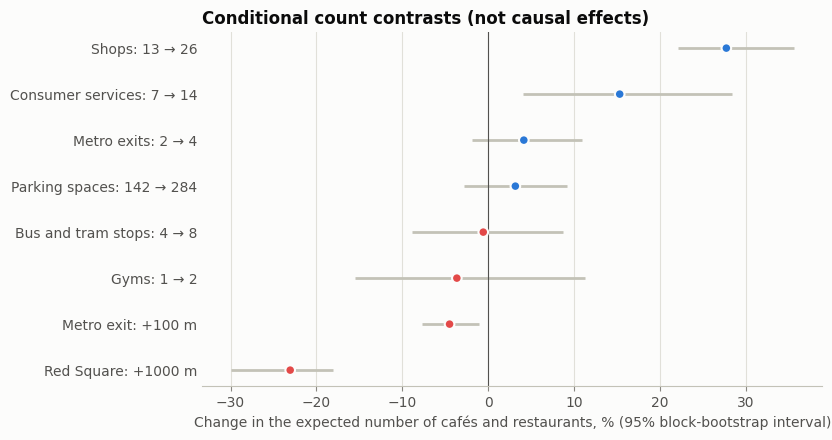

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.6))
positions = np.arange(len(effects))
ax.hlines(positions, effects["95% low"], effects["95% high"], color=AXIS, linewidth=2)
ax.scatter(effects["effect, %"], positions, s=48, color=[BLUE if v > 0 else RED for v in effects["effect, %"]],
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.axvline(0, color=INK_2, linewidth=0.8)
ax.set_yticks(positions, effects["change"])
ax.set_xlabel("Change in the expected number of cafés and restaurants, % (95% block-bootstrap interval)")
ax.set_title("Conditional count contrasts (not causal effects)")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig6_model_effects")
plt.show()

## 7. Residual screening and split sensitivity

The score is `(observed - predicted) / sqrt(predicted + predicted²/theta)`, averaged over three
catchments after averaging predictions over 50 splits. Theta is a moment estimate of predictive
error scale; if excess dispersion is nonpositive, the code uses the Poisson limit. The score is
descriptive, not a calibrated z statistic or proof of a shortage of cafés.

Eligibility must hold at two radii for the aggregate predictions and in at least 40 of the
50 individual repeats. Split ranges and inclusion frequencies accompany the complete output;
they measure algorithm sensitivity and are not probabilities of commercial success.

In [18]:
RADII = modelling.RADII
features_by_radius = {r: features if r == RADIUS_M else build_features(cells, **layers, radius=r) for r in RADII}


def progress(done, total):
    if done % 10 == 0:
        print(f"Nested spatial validation: {done}/{total} splits")


result_2019 = modelling.repeated_screening(features_by_radius, CELL_XY, include_education=False, progress=progress)
runs = result_2019["runs"]
run, theta = runs[300], result_2019["theta"][300]
opportunity_score, eligible = result_2019["score"], result_2019["eligible"]
residual = y - run["expected"]
dispersion = float((residual**2 / run["expected"]).mean())
print(f"2019: D² of averaged out-of-fold predictions = {result_2019['d2']:.3f}; theta = {theta:.2f}; "
      f"{eligible.sum()} eligible cells")


def score_table(features, result, exits):
    _, nearest_exit = nearest(xy_array(cells), xy_array(exits))
    return cells[["address"]].assign(
        type=cluster, nearest_metro=exits["station"].to_numpy()[nearest_exit],
        metro_m=features["metro_distance"].round(), center_km=(features["center_distance"] / 1000).round(1),
        competitors=features["competitors"], expected=result["runs"][300]["expected"],
        score=result["score"], eligible=result["eligible"],
        shops=features["shops"], services=features["services"],
        lat=cells["lat"].round(6), lon=cells["lon"].round(6),
    ).join(result["stability"])


top_ten = modelling.top_ten
scores = score_table(features, result_2019, metro)
shortlist = top_ten(scores)
shortlist.drop(columns=["eligible", "lat", "lon"])

Nested spatial validation: 10/50 splits


Nested spatial validation: 20/50 splits


Nested spatial validation: 30/50 splits


Nested spatial validation: 40/50 splits


Nested spatial validation: 50/50 splits
2019: D² of averaged out-of-fold predictions = 0.664; theta = 4.11; 114 eligible cells


,rank,address,type,nearest_metro,metro_m,center_km,competitors,expected,score,shops,services,eligibility_frequency,top10_frequency,expected_p10,expected_p90,score_p10,score_p90
cell_id,,,,,,,,,,,,,,,,,
149,1,"Stroykovskaya Street, 10",Residential belt,Пролетарская,366.0,3.9,1,11.19,-1.57,20,14,1.00,1.00,10.31,11.93,-1.60,-1.47
337,2,4th Maryinoy Roschi Drive,Transit hubs,Марьина роща,114.0,4.9,4,20.52,-1.42,139,12,1.00,1.00,17.52,22.99,-1.47,-1.29
2,3,"Leninsky Avenue, 39с1",Transit hubs,Ленинский проспект,138.0,5.6,1,9.44,-1.34,25,12,0.94,0.94,7.95,10.95,-1.41,-1.18
146,4,Goncharnaya Embankment,Central neighbourhoods,Таганская,377.0,2.3,2,14.08,-1.25,14,12,1.00,0.98,13.31,15.08,-1.30,-1.16
128,5,"Krestyanskaya Square, 10с28",Residential belt,Пролетарская,411.0,3.3,1,7.22,-1.25,6,6,0.86,0.86,6.26,7.97,-1.29,-1.16
129,6,"Krutitsky Val Street, 3с1",Transit hubs,Пролетарская,134.0,3.8,9,27.50,-1.22,53,30,1.00,0.94,24.98,30.35,-1.27,-1.10
34,7,"Komsomolsky Avenue, 35",Residential belt,Фрунзенская,466.0,4.3,2,10.90,-1.21,26,14,1.00,0.92,10.22,11.82,-1.25,-1.12
339,8,"Tsentralniy Administrative Okrug, Meschanskiy ...",Residential belt,Рижская,171.0,4.6,2,8.13,-1.21,22,2,1.00,0.92,7.33,9.10,-1.24,-1.11
174,9,"Sergeya Makeyeva Street, 12",Residential belt,Улица 1905 года,326.0,4.4,5,15.95,-1.18,86,12,1.00,0.86,14.89,16.83,-1.23,-1.08


### Sensitivity to catchment size

These ranks use each radius's averaged predictions and screening rule. They are complementary
to the repeated-split frequencies, not independent statistical confirmations.

In [19]:
single_radius_ranks = pd.DataFrame(
    {f"rank at {r} m": runs[r]["gap"].where(runs[r]["eligible"]).rank(method="min") for r in RADII}
).loc[shortlist.index].astype("Int64")
shortlist[["rank", "address", "nearest_metro"]].join(single_radius_ranks)

,rank,address,nearest_metro,rank at 250 m,rank at 300 m,rank at 400 m
cell_id,,,,,,
149,1,"Stroykovskaya Street, 10",Пролетарская,1,1,2
337,2,4th Maryinoy Roschi Drive,Марьина роща,6,4,3
2,3,"Leninsky Avenue, 39с1",Ленинский проспект,3,3,<NA>
146,4,Goncharnaya Embankment,Таганская,8,2,18
128,5,"Krestyanskaya Square, 10с28",Пролетарская,<NA>,6,22
129,6,"Krutitsky Val Street, 3с1",Пролетарская,9,7,10
34,7,"Komsomolsky Avenue, 35",Фрунзенская,10,5,15
339,8,"Tsentralniy Administrative Okrug, Meschanskiy ...",Рижская,4,9,16
174,9,"Sergeya Makeyeva Street, 12",Улица 1905 года,20,10,5


Fast food is a separate sensitivity variant. It uses the same nested validation, repeats and
eligibility rule; it changes what counts as a competitor, not the measured business outcome.

In [20]:
fast_food_2019 = modelling.repeated_screening(features_by_radius, CELL_XY, include_education=False,
                                             competitor_columns=("competitors", "fast_food"), progress=progress)
fast_food_top = top_ten(pd.DataFrame({"score": fast_food_2019["score"], "eligible": fast_food_2019["eligible"]})).index
kept = shortlist.index.intersection(fast_food_top)
print(f"{len(kept)} of {len(shortlist)} cells remain in the fast-food sensitivity shortlist")

Nested spatial validation: 10/50 splits


Nested spatial validation: 20/50 splits


Nested spatial validation: 30/50 splits


Nested spatial validation: 40/50 splits


Nested spatial validation: 50/50 splits
8 of 10 cells remain in the fast-food sensitivity shortlist


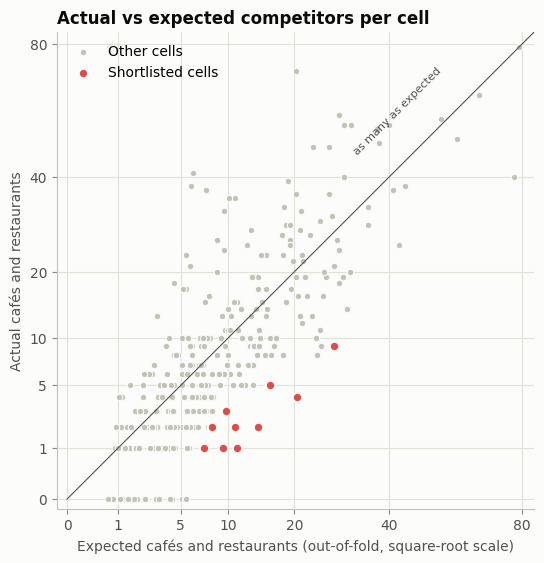

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 6.2))
others = scores.drop(shortlist.index)
ax.scatter(np.sqrt(others["expected"]), np.sqrt(others["competitors"]), s=22, color=AXIS, edgecolor=SURFACE,
           linewidth=0.8, label="Other cells")
ax.scatter(np.sqrt(shortlist["expected"]), np.sqrt(shortlist["competitors"]), s=46, color=RED, edgecolor=SURFACE,
           linewidth=1.5, label="Shortlisted cells", zorder=3)
limit = np.sqrt(max(scores["expected"].max(), scores["competitors"].max())) + 0.3
ax.plot([0, limit], [0, limit], color=INK_2, linewidth=0.8)
ax.annotate("as many as expected", (limit * 0.72, limit * 0.72), xytext=(-4, 6), textcoords="offset points",
            rotation=45, color=INK_2, fontsize=8, ha="center")
ticks = [0, 1, 5, 10, 20, 40, 80]
ax.set_xticks(np.sqrt(ticks), ticks)
ax.set_yticks(np.sqrt(ticks), ticks)
ax.set_xlim(-0.2, limit)
ax.set_ylim(-0.2, limit)
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel("Expected cafés and restaurants (out-of-fold, square-root scale)")
ax.set_ylabel("Actual cafés and restaurants")
ax.set_title("Actual vs expected competitors per cell")
ax.legend(loc="upper left")
save(fig, "fig7_expected_vs_actual")
plt.show()

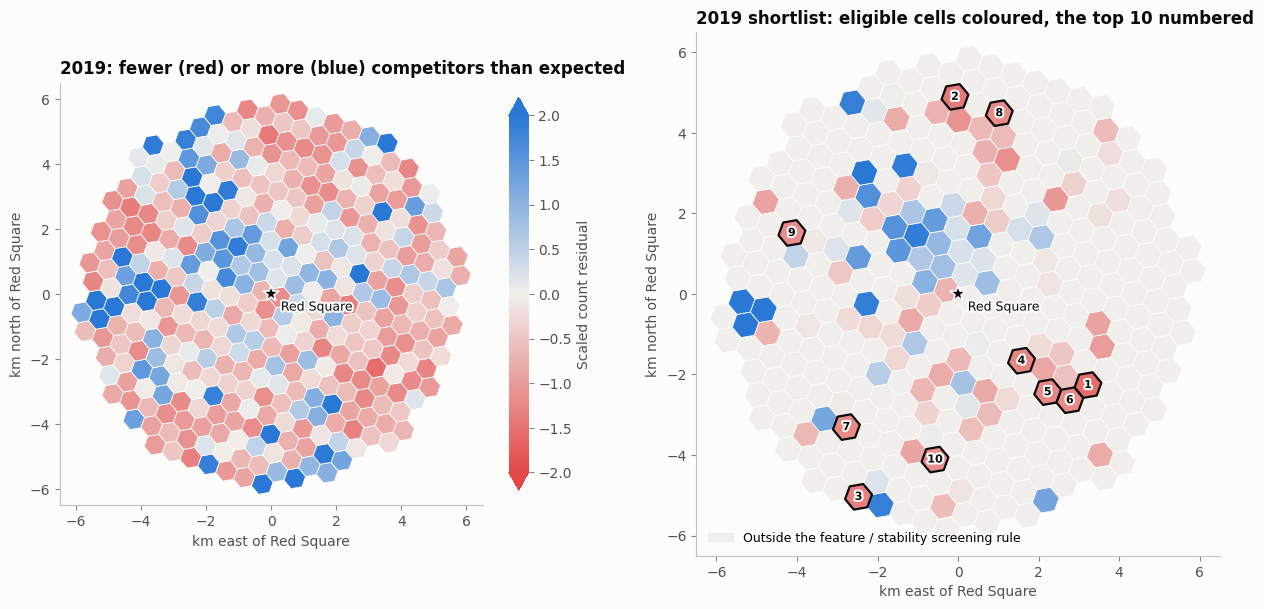

In [22]:
score_norm = Normalize(vmin=-2, vmax=2)


def opportunity_figure(scores, shortlist, year, name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.8))
    tiles = hex_map(axes[0], scores["score"], DIVERGING, score_norm,
                    f"{year}: fewer (red) or more (blue) competitors than expected")
    colorbar = fig.colorbar(tiles, ax=axes[0], shrink=0.75, extend="both")
    colorbar.set_label("Scaled count residual", color=INK_2)
    colorbar.outline.set_visible(False)
    hex_map(axes[1], np.zeros(len(cells)), ListedColormap([NEUTRAL]), Normalize(0, 1),
            f"{year} shortlist: eligible cells coloured, the top 10 numbered")
    eligible_cells = scores["eligible"].to_numpy()
    axes[1].add_collection(PolyCollection(HEX_KM[eligible_cells], array=scores.loc[eligible_cells, "score"].to_numpy(),
                                          cmap=DIVERGING, norm=score_norm, edgecolor=SURFACE, linewidth=0.6))
    axes[1].add_collection(PolyCollection(HEX_KM[[cells.index.get_loc(i) for i in shortlist.index]],
                                          facecolor="none", edgecolor=INK, linewidth=1.6))
    for cell_id, row in shortlist.iterrows():
        x, y_km = CELL_KM[cells.index.get_loc(cell_id)]
        axes[1].text(x, y_km, str(row["rank"]), ha="center", va="center", fontsize=8, fontweight="bold", color=INK,
                     path_effects=HALO)
    not_eligible = Patch(color=NEUTRAL, label="Outside the feature / stability screening rule")
    axes[1].legend(handles=[not_eligible], loc="lower left", fontsize=9)
    save(fig, name)
    plt.show()


opportunity_figure(scores, shortlist, 2019, "fig8_opportunity_map_2019")

## 8. Comparing sources: 2019 register and OpenStreetMap 2026

The snapshots differ in coverage, categories and completeness. Similar total counts do not make
their local differences verified openings or closures. Quintiles are selected using the 2019
residuals, so regression to the mean can itself produce apparent convergence. The following
tables describe the source contrast; they do not validate unmet demand or estimate the speed
at which a market gap is filled.

In [23]:
osm_competitors = osm_catering[osm_catering["is_competitor"]]
count_2026 = pd.Series(count_within(xy_array(cells), xy_array(osm_competitors), RADIUS_M), index=cells.index)
growth = np.log((count_2026 + 1) / (y + 1))
print(f"Cafés and restaurants within 300 m of the cells: {y.sum():,} in the 2019 register, "
      f"{count_2026.sum():,} in OpenStreetMap 2026")

quintile_names = ["1: lowest residuals", "2", "3", "4", "5: highest residuals"]
by_quintile = (
    pd.DataFrame({"quintile": pd.qcut(scores["score"], 5, labels=quintile_names), "2019": y, "2026": count_2026})
    .groupby("quintile", observed=True)
    .agg(cells=("2019", "size"), venues_2019=("2019", "sum"), venues_2026=("2026", "sum"))
)
by_quintile["change"] = by_quintile["venues_2026"] / by_quintile["venues_2019"]
by_quintile.round(2)

Cafés and restaurants within 300 m of the cells: 3,659 in the 2019 register, 3,691 in OpenStreetMap 2026


,cells,venues_2019,venues_2026,change
quintile,,,,
1: lowest residuals,73,102,208,2.04
2,73,371,438,1.18
3,72,604,697,1.15
4,73,1065,1000,0.94
5: highest residuals,73,1517,1348,0.89


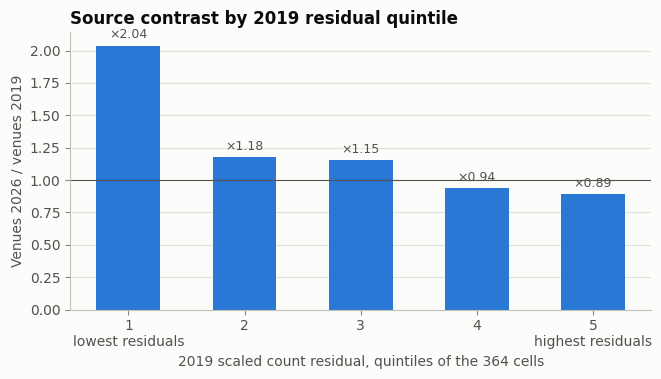

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.bar(range(len(by_quintile)), by_quintile["change"], color=BLUE, width=0.55)
ax.bar_label(bars, labels=[f"×{v:.2f}" for v in by_quintile["change"]], padding=3, color=INK_2, fontsize=9)
ax.axhline(1, color=INK_2, linewidth=0.8)
ax.set_xticks(range(len(by_quintile)), [q.replace(": ", "\n") for q in by_quintile.index])
ax.set_ylabel("Venues 2026 / venues 2019")
ax.set_xlabel("2019 scaled count residual, quintiles of the 364 cells")
ax.set_title("Source contrast by 2019 residual quintile")
ax.yaxis.grid(True)
ax.set_axisbelow(True)
save(fig, "fig9_look_forward")
plt.show()

The baseline-adjusted regression asks whether the count prediction is associated with
`log(N2026 + 1)` after conditioning on `log(N2019 + 1)`. Expressing the response as their
difference yields the same coefficient on the prediction. Its exponentiated coefficient is a
ratio of conditional geometric means of `N2026 + 1`, not an arithmetic count-growth percentage.
The block bootstrap conditions on the fitted 2019 predictions and does not model source errors.

In [25]:
change_design = np.column_stack([np.ones(len(y)), np.log1p(y), np.log(run["expected"])])


def expectation_slope(design, rows):
    """Coefficient of the log expectation in the least-squares fit of the log change on `design`."""
    coefficients, *_ = np.linalg.lstsq(design[rows], growth.to_numpy()[rows], rcond=None)
    return coefficients[2]


def slope_with_interval(design):
    boot = [expectation_slope(design, rows) for rows in forward_rows]
    return expectation_slope(design, np.arange(len(y))), *np.percentile(boot, [2.5, 97.5])


forward_rng = np.random.RandomState(1)
forward_rows = [
    np.concatenate([np.flatnonzero(blocks == b) for b in forward_rng.choice(block_ids, size=len(block_ids))])
    for _ in range(1000)
]
forward_slope, forward_low, forward_high = slope_with_interval(change_design)
print(f"At equal 2019 counts, twice the expected count means {2**forward_slope - 1:+.0%} "
      "higher conditional geometric mean of (2026 count + 1) "
      f"(95% interval {2**forward_low - 1:+.0%} to {2**forward_high - 1:+.0%}).")

shortlist_2026 = shortlist[["rank", "address", "nearest_metro", "competitors"]]
shortlist_2026 = shortlist_2026.assign(in_2026=count_2026[shortlist.index])
print(f"The ten shortlisted cells: {shortlist_2026['competitors'].sum()} cafés and restaurants in 2019, "
      f"{shortlist_2026['in_2026'].sum()} in 2026.")
shortlist_2026.rename(columns={"competitors": "in_2019"})

At equal 2019 counts, twice the expected count means +11% higher conditional geometric mean of (2026 count + 1) (95% interval +2% to +19%).
The ten shortlisted cells: 30 cafés and restaurants in 2019, 54 in 2026.


,rank,address,nearest_metro,in_2019,in_2026
cell_id,,,,,
149,1,"Stroykovskaya Street, 10",Пролетарская,1,7
337,2,4th Maryinoy Roschi Drive,Марьина роща,4,7
2,3,"Leninsky Avenue, 39с1",Ленинский проспект,1,5
146,4,Goncharnaya Embankment,Таганская,2,7
128,5,"Krestyanskaya Square, 10с28",Пролетарская,1,2
129,6,"Krutitsky Val Street, 3с1",Пролетарская,9,9
34,7,"Komsomolsky Avenue, 35",Фрунзенская,2,6
339,8,"Tsentralniy Administrative Okrug, Meschanskiy ...",Рижская,2,0
174,9,"Sergeya Makeyeva Street, 12",Улица 1905 года,5,7


### Adjustment for geography

Add the distance to Red Square as a sensitivity adjustment. It cannot separately identify
effects of the pandemic, remote work, tourism, war or sanctions. Those explanations would need
their own measurements and research design. Differences by cluster below are descriptive;
the clusters include baseline café counts and are not an independent causal control.

In [26]:
distance_design = np.column_stack([change_design, features["center_distance"] / 1000])
distance_slope, distance_low, distance_high = slope_with_interval(distance_design)
print(f"With the distance to Red Square in the fit, twice the expected count means {2**distance_slope - 1:+.0%} "
      f"(95% interval {2**distance_low - 1:+.0%} to {2**distance_high - 1:+.0%}).")

outer = features["center_distance"] > 3000
outer_quintiles = (
    pd.DataFrame({"quintile": pd.qcut(scores["score"], 5, labels=quintile_names), "2019": y, "2026": count_2026})
    .loc[outer]
    .groupby("quintile", observed=True)[["2019", "2026"]]
    .sum()
)
outer_change = outer_quintiles["2026"] / outer_quintiles["2019"]
print(f"Beyond 3 km from Red Square ({outer.sum()} cells), venues 2026 / 2019 by quintile: "
      + ", ".join(f"×{value:.2f}" for value in outer_change))

by_type = (
    pd.DataFrame({"type": cluster, "venues_2019": y, "venues_2026": count_2026})
    .groupby("type")
    .agg(cells=("venues_2019", "size"), venues_2019=("venues_2019", "sum"), venues_2026=("venues_2026", "sum"))
    .reindex(CLUSTER_ORDER)
)
by_type["change"] = by_type["venues_2026"] / by_type["venues_2019"]
by_type.round(2)

With the distance to Red Square in the fit, twice the expected count means +5% (95% interval -4% to +13%).
Beyond 3 km from Red Square (268 cells), venues 2026 / 2019 by quintile: ×2.05, ×1.21, ×1.21, ×1.04, ×0.82


,cells,venues_2019,venues_2026,change
type,,,,
Transit hubs,50,1474,1275,0.86
Central neighbourhoods,98,1510,1557,1.03
Residential belt,141,603,694,1.15
"Parks, rail and industrial land",75,72,165,2.29


Read the coefficient and interval produced above, including whether zero is covered. Even a
positive association cannot by itself resolve measurement error or omitted variables. Two
snapshots do not establish how quickly areas changed or whether a new café would be profitable.

## 9. The 2026 screening shortlist

Repeat the analysis with OpenStreetMap counts and surroundings. Metro/MCC/MCD entrance counts
are proxies for infrastructure, not measured passenger volumes. Shops and services do not
establish that premises are available to rent. Parking remains a 2019 layer; education is now
included from the contemporaneous 2026 snapshot.

In [27]:
footfall_2026 = data.load_osm_demand()
footfall_names = {
    "metro": "Metro entrances (2026: metro, MCC and MCD)",
    "bus": "Bus and tram stops",
    "shops": "Shops",
    "services": "Consumer services",
    "fitness": "Gyms (2019: municipal sports centres)",
}


def within_6km(frame):
    return int((distance_from(frame, *RED_SQUARE) <= 6000).sum())


footfall_counts = pd.DataFrame(
    {year: {footfall_names[k]: within_6km(source[k]) for k in footfall_names}
     for year, source in (("2019", layers), ("2026", footfall_2026))}
)
footfall_counts

,2019,2026
"Metro entrances (2026: metro, MCC and MCD)",289,349
Bus and tram stops,1654,1772
Shops,12695,9686
Consumer services,3031,3328
Gyms (2019: municipal sports centres),43,178


The current shortlist uses the same 50 nested spatial splits and 80% eligibility rule. The
historical-surroundings and fast-food variants below are also recomputed over the same seeds.
All displayed expectations refer to conditional recorded counts, not required market capacity.

In [28]:
layers_2026 = {**layers, **footfall_2026, "catering": osm_catering}
features_by_radius_2026 = {r: build_features(cells, **layers_2026, radius=r) for r in RADII}
features_2026 = features_by_radius_2026[300]
result_2026 = modelling.repeated_screening(features_by_radius_2026, CELL_XY, progress=progress)
runs_2026, run_2026 = result_2026["runs"], result_2026["runs"][300]
theta_2026, d2_2026 = result_2026["theta"][300], result_2026["d2"]
score_2026, eligible_2026 = result_2026["score"], result_2026["eligible"]
scores_2026 = score_table(features_2026, result_2026, footfall_2026["metro"])
shortlist_now = top_ten(scores_2026)
print(f"2026: D² = {d2_2026:.3f}; theta = {theta_2026:.2f}; {eligible_2026.sum()} eligible cells")

old_footfall = {r: build_features(cells, **{**layers, "catering": osm_catering}, radius=r) for r in RADII}
old_result = modelling.repeated_screening(old_footfall, CELL_XY, include_education=False, progress=progress)
d2_old_footfall = old_result["d2"]
old_rank = old_result["score"].where(old_result["eligible"]).rank(method="min").loc[shortlist_now.index].astype("Int64")
ranks_2026 = pd.DataFrame(
    {f"rank at {r} m": runs_2026[r]["gap"].where(runs_2026[r]["eligible"]).rank(method="min") for r in RADII}
).loc[shortlist_now.index].astype("Int64")
fast_food_2026 = modelling.repeated_screening(features_by_radius_2026, CELL_XY,
                                             competitor_columns=("competitors", "fast_food"), progress=progress)
fast_food_top_2026 = top_ten(
    pd.DataFrame({"score": fast_food_2026["score"], "eligible": fast_food_2026["eligible"]})
).index
kept_2026 = shortlist_now.index.intersection(fast_food_top_2026)
print(f"{len(kept_2026)} of {len(shortlist_now)} remain with fast food included")
shortlist_now[["rank", "address", "nearest_metro", "competitors", "expected", "score",
               "eligibility_frequency", "top10_frequency", "expected_p10", "expected_p90"]].join(ranks_2026)

Nested spatial validation: 10/50 splits


Nested spatial validation: 20/50 splits


Nested spatial validation: 30/50 splits


Nested spatial validation: 40/50 splits


Nested spatial validation: 50/50 splits
2026: D² = 0.668; theta = 4.78; 120 eligible cells


...

Nested spatial validation: 20/50 splits


Nested spatial validation: 30/50 splits


Nested spatial validation: 40/50 splits


Nested spatial validation: 50/50 splits
7 of 10 remain with fast food included


,rank,address,nearest_metro,competitors,expected,score,eligibility_frequency,top10_frequency,expected_p10,expected_p90,rank at 250 m,rank at 300 m,rank at 400 m
cell_id,,,,,,,,,,,,,
60,1,"Kutuzovsky Avenue, 35",Кутузовская,1,9.13,-1.63,1.00,1.00,8.16,10.02,3,1,1
324,2,Festivalny Park,Марьина Роща,1,7.61,-1.56,1.00,1.00,7.05,8.04,6,3,2
303,3,Soldatsky Lane,Лефортово,2,10.60,-1.53,0.98,0.96,7.77,12.63,4,4,<NA>
307,4,Savyolovsky Drive,Савёловская,1,7.61,-1.50,1.00,1.00,7.15,8.14,7,2,3
192,5,"Khoroshyovskoye Highway, вл1",Беговая,4,10.87,-1.34,0.98,0.86,8.12,13.40,8,10,5
129,6,"Krutitsky Val Street, 3с1",Пролетарская,9,27.84,-1.31,1.00,0.92,25.89,29.88,10,8,9
188,7,"Rogozhsky Val Street, 9/2с2",Римская,4,11.48,-1.29,1.00,0.92,10.23,12.61,21,9,4
61,8,Kiyevskaya Street,Студенческая,4,9.69,-1.26,0.96,0.72,7.83,11.28,16,17,6
348,9,"Severo-Vostochniy Administrative Okrug, Maryin...",Марьина Роща,3,11.72,-1.26,1.00,0.76,10.33,13.21,9,7,15


The frequencies above measure sensitivity to split assignment, not success probabilities.
Cells excluded by the stability policy remain visible in the full CSV and on the map.
Changes from the historical list can reflect both real differences and source coverage.

Lefortovo station opened on **27 March 2020**, according to
[Mosmetrostroy](https://www.metrostroy.ru/projects/1059-lefortovo-severo-vostochnyj-uchastok-tpk/).
Its appearance after 2019 does not establish that cafés have not had time to respond, nor do
two snapshots date the onset of a residual. Similar caution applies to the Mitkovo areas.

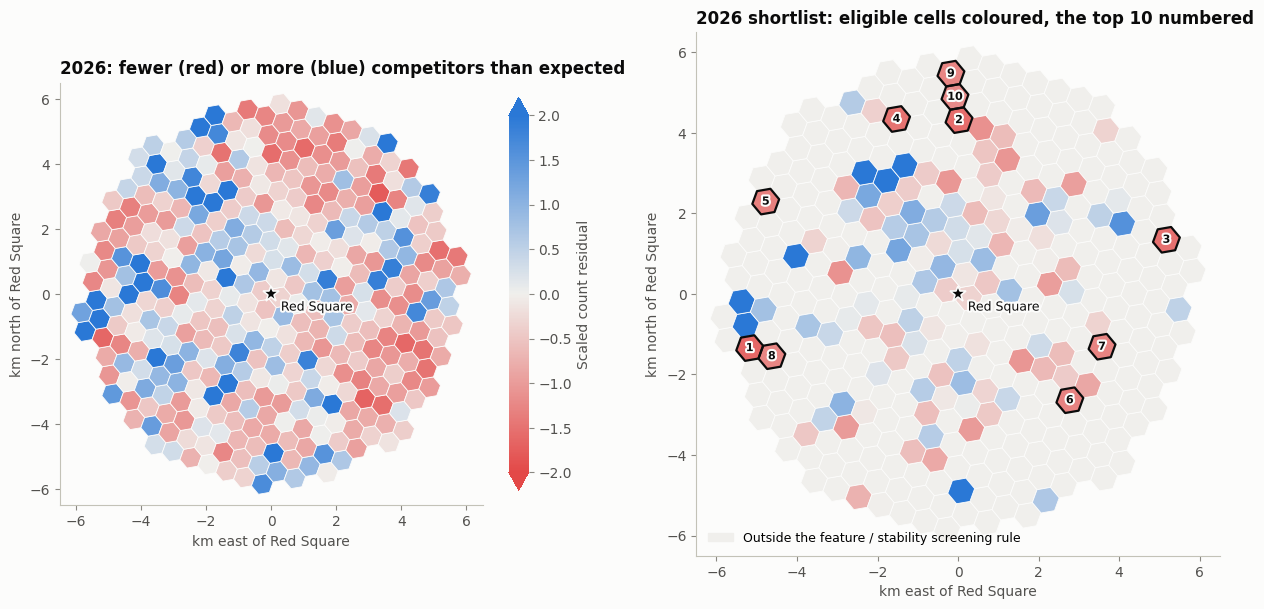

In [29]:
opportunity_figure(scores_2026, shortlist_now, 2026, "fig10_opportunity_map_2026")

### Interactive map

The 2026 scores with the 2026 shortlist; the 2019 scores and shortlist are extra layers. Hover a
cell for its numbers. The map is also saved as `report/cafe_opportunity_map.html`.

In [30]:
score_colors = bcm.LinearColormap([RED, NEUTRAL, BLUE], vmin=-2, vmax=2,
                                  caption="Scaled residual: red = fewer recorded venues than predicted")
map_columns = ["address", "type", "nearest_metro", "metro_m", "competitors", "expected", "score", "eligible",
               "eligibility_frequency", "top10_frequency", "expected_p10", "expected_p90"]
map_aliases = ["Address", "Type", "Nearest metro", "Metro exit, m", "Recorded venues", "Expected",
               "Scaled residual (not a z statistic)", "Eligible for screening", "Eligibility frequency",
               "Top-10 frequency", "Prediction 10th percentile", "Prediction 90th percentile"]
opportunity_map = base_map()
for year, year_scores, show in ((2026, scores_2026, True), (2019, scores, False)):
    table = year_scores.assign(eligible=year_scores["eligible"].map({True: "yes", False: "no"}))[map_columns]
    hex_layer(table, year_scores["score"].clip(-2, 2).map(score_colors), map_columns, map_aliases,
              f"Count residual {year}", opacity=0.6, show=show).add_to(opportunity_map)
for year, year_shortlist, show in ((2026, shortlist_now, True), (2019, shortlist, False)):
    shortlist_layer = folium.FeatureGroup(name=f"Shortlist {year}", show=show)
    background, foreground = (INK, SURFACE) if year == 2026 else (SURFACE, INK)
    for _, row in year_shortlist.iterrows():
        popup = (f"<b>{year} #{row['rank']} {escape(row['address'])}</b><br>Metro {escape(row['nearest_metro'])}, "
                 f"{row['metro_m']:.0f} m<br>{row['competitors']} cafés and restaurants within 300 m straight-line, "
                 f"{row['expected']:.1f} expected<br>{row['shops']} shops, {row['services']} services")
        folium.Marker(
            [row["lat"], row["lon"]],
            icon=folium.DivIcon(
                html=f'<div style="width:24px;height:24px;border-radius:12px;background:{background};'
                     f'color:{foreground};border:2px solid {INK};box-sizing:border-box;'
                     f'font:600 12px/20px system-ui,sans-serif;text-align:center">{row["rank"]}</div>',
                icon_size=(24, 24), icon_anchor=(12, 12)),
            tooltip=f"{year} #{row['rank']} {escape(row['address'])}",
            popup=folium.Popup(popup, max_width=320),
        ).add_to(shortlist_layer)
    shortlist_layer.add_to(opportunity_map)
score_colors.add_to(opportunity_map)
folium.LayerControl(collapsed=False).add_to(opportunity_map)
map_path = REPORT / "cafe_opportunity_map.html"
opportunity_map.save(map_path)
map_path.write_text("\n".join(line.rstrip() for line in map_path.read_text().splitlines()) + "\n")

# Columns that differ between the years get a _2019 or _2026 suffix.
year_columns = ["nearest_metro", "metro_m", "shops", "services", "competitors", "expected", "score", "eligible",
                "eligibility_frequency", "top10_frequency", "expected_p10", "expected_p90", "score_p10", "score_p90"]
cell_scores = scores.drop(columns=year_columns).join(scores[year_columns].add_suffix("_2019")).join(
    scores_2026[year_columns].add_suffix("_2026")
)
cell_scores.to_csv(REPORT / "cell_scores.csv", index_label="cell_id")
shortlist.drop(columns=["eligible"]).to_csv(REPORT / "shortlist_2019.csv", index_label="cell_id")
shortlist_now.drop(columns=["eligible"]).to_csv(REPORT / "shortlist_2026.csv", index_label="cell_id")
opportunity_map

In [31]:
import platform
from importlib.metadata import version


# The numbers quoted in the report, for scripts/build_report_page.py.
def as_json(obj, orient=None):
    """A pandas object as plain JSON values (numpy types become Python ones, NaN becomes null)."""
    return json.loads(obj.to_json(orient=orient, force_ascii=False))


profile_columns = ["cells", "competitors", "metro_exits", "shops", "services", "metro_distance", "center_distance"]
summary = {
    "osm_date": osm_date,
    "runtime": {"python": platform.python_version(),
                **{name: version(name) for name in ("numpy", "pandas", "scipy", "scikit-learn",
                                                   "pyproj", "matplotlib", "folium")}},
    "catering_within_6km": as_json(composition["venues"]),
    "competitors_within_6km": len(competitors),
    "competitor_seats": int(competitors["seats"].sum()),
    "chain_share": float(competitors["is_chain"].mean()),
    "top_chains": as_json(chain_counts.head(15)),
    "spearman": as_json(rho),
    "typology": as_json(cluster_profile[profile_columns], orient="index"),
    "silhouette_k4": float(k_scores.loc[K, "silhouette"]),
    "model_d2": as_json(model_comparison.iloc[:, 0]),
    "alpha": float(ALPHA),
    "validation": {
        "repeats": modelling.REPEATS, "seeds": result_2019["seeds"], "buffer_m": modelling.BUFFER_M,
        "block_m": modelling.BLOCK_M, "minimum_eligibility_frequency": modelling.MIN_ELIGIBILITY_FREQUENCY,
        "alpha_grid": list(modelling.ALPHAS), "d2": result_2019["d2"],
        "repeat_d2_range": [min(result_2019["repeat_d2"]), max(result_2019["repeat_d2"])],
        "education_2019": False,
    },
    "effects": as_json(effects, orient="index"),
    "dispersion": float(dispersion),
    "theta": float(theta) if np.isfinite(theta) else None,
    "eligible_cells": int(eligible.sum()),
    "single_radius_ranks": as_json(single_radius_ranks.astype(float), orient="index"),
    "kept_with_fast_food": [int(rank) for rank in shortlist.loc[kept, "rank"]],
    "look_forward": {
        "venues_2019": int(y.sum()),
        "venues_2026": int(count_2026.sum()),
        "by_quintile": as_json(by_quintile.reset_index(), orient="records"),
        "slope": float(forward_slope),
        "slope_low": float(forward_low),
        "slope_high": float(forward_high),
        "distance_slope": float(distance_slope),
        "distance_slope_low": float(distance_low),
        "distance_slope_high": float(distance_high),
        "outer_cells": int(outer.sum()),
        "outer_change": [float(value) for value in outer_change],
        "by_type": as_json(by_type, orient="index"),
        "shortlist": as_json(shortlist_2026.reset_index(), orient="records"),
    },
    "most_saturated": as_json(
        scores.sort_values("score", ascending=False).head(6)[
            ["address", "nearest_metro", "type", "competitors", "expected", "score"]
        ].reset_index(),
        orient="records",
    ),
}
osm_central = osm_catering[distance_from(osm_catering, *RED_SQUARE) <= 6000]
summary["now"] = {
    "osm_catering_within_6km": as_json(osm_central["amenity"].value_counts()),
    "competitors_within_6km": int(osm_central["is_competitor"].sum()),
    "footfall_within_6km": as_json(footfall_counts.set_axis(list(footfall_names), axis=0), orient="index"),
    "d2": float(d2_2026),
    "repeat_d2_range": [min(result_2026["repeat_d2"]), max(result_2026["repeat_d2"])],
    "stability": as_json(result_2026["stability"], orient="index"),
    "d2_2019_footfall": float(d2_old_footfall),
    "ranks_with_2019_footfall": as_json(old_rank.astype(float)),
    "theta": float(theta_2026) if np.isfinite(theta_2026) else None,
    "eligible_cells": int(eligible_2026.sum()),
    "single_radius_ranks": as_json(ranks_2026.astype(float), orient="index"),
    "kept_with_fast_food": [int(rank) for rank in shortlist_now.loc[kept_2026, "rank"]],
}
for year, result in ((2019, result_2019), (2026, result_2026)):
    result["stability"].to_csv(REPORT / f"screening_stability_{year}.csv", index_label="cell_id")
    pd.DataFrame(result["selected_alphas"]).to_csv(REPORT / f"cv_folds_{year}.csv", index=False)
_ = (REPORT / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=1) + "\n", encoding="utf-8")

## 10. Results and interpretation

The tables below are generated from the current run. Expectations and scores are retained at
full precision for ranking; notebook display formatting does not change the stored numbers.
Negative scores identify count residuals to investigate. They neither establish a missing number
of businesses nor rank expected profits. Split frequencies and ranges are in the exported CSVs.

In [32]:
summary_columns = ["rank", "address", "nearest_metro", "metro_m", "center_km", "competitors", "expected", "score"]
shortlist[summary_columns].set_index("rank")

,address,nearest_metro,metro_m,center_km,competitors,expected,score
rank,,,,,,,
1,"Stroykovskaya Street, 10",Пролетарская,366.0,3.9,1,11.19,-1.57
2,4th Maryinoy Roschi Drive,Марьина роща,114.0,4.9,4,20.52,-1.42
3,"Leninsky Avenue, 39с1",Ленинский проспект,138.0,5.6,1,9.44,-1.34
4,Goncharnaya Embankment,Таганская,377.0,2.3,2,14.08,-1.25
5,"Krestyanskaya Square, 10с28",Пролетарская,411.0,3.3,1,7.22,-1.25
6,"Krutitsky Val Street, 3с1",Пролетарская,134.0,3.8,9,27.50,-1.22
7,"Komsomolsky Avenue, 35",Фрунзенская,466.0,4.3,2,10.90,-1.21
8,"Tsentralniy Administrative Okrug, Meschanskiy ...",Рижская,171.0,4.6,2,8.13,-1.21
9,"Sergeya Makeyeva Street, 12",Улица 1905 года,326.0,4.4,5,15.95,-1.18


The historical shortlist below was reconstructed using the corrected method and 2019 input
layers only. Its count comparison is between sources and must not be described as a verified
history of actual openings or a forecast issued in 2019.

The 2026 table is a fieldwork shortlist subject to the disclosed filters and stability policy.

In [33]:
shortlist_now[summary_columns].assign(in_2019=y[shortlist_now.index]).set_index("rank")

,address,nearest_metro,metro_m,center_km,competitors,expected,score,in_2019
rank,,,,,,,,
1,"Kutuzovsky Avenue, 35",Кутузовская,309.0,5.3,1,9.13,-1.63,2
2,Festivalny Park,Марьина Роща,248.0,4.3,1,7.61,-1.56,3
3,Soldatsky Lane,Лефортово,228.0,5.3,2,10.60,-1.53,2
4,Savyolovsky Drive,Савёловская,381.0,4.6,1,7.61,-1.50,9
5,"Khoroshyovskoye Highway, вл1",Беговая,4.0,5.3,4,10.87,-1.34,8
6,"Krutitsky Val Street, 3с1",Пролетарская,131.0,3.8,9,27.84,-1.31,9
7,"Rogozhsky Val Street, 9/2с2",Римская,440.0,3.8,4,11.48,-1.29,8
8,Kiyevskaya Street,Студенческая,6.0,4.9,4,9.69,-1.26,5
9,"Severo-Vostochniy Administrative Okrug, Maryin...",Марьина Роща,206.0,5.5,3,11.72,-1.26,5


### Limits of the inference

- Recorded venues and infrastructure do not measure consumer demand, available premises or profit.
- Counts are straight-line catchments; road crossings, rivers, railways and private access are absent.
- OpenStreetMap and the city register differ in completeness and classifications. Matching total
  counts does not make their local changes directly comparable. Education is used only for 2026;
  parking still uses 2019 capacity in both periods.
- Cafés and restaurants are counted equally regardless of size, price, seats or concept. The
  fast-food variant checks one definition choice, not the full competitive landscape.
- Repeated CV tests sensitivity to model training; its frequencies do not establish site quality.
- The conditional temporal association and descriptive clusters do not identify effects of
  particular economic events or show how fast an apparent gap was filled.

In [34]:
scores.sort_values("score", ascending=False).head(6)[
    ["address", "nearest_metro", "type", "competitors", "expected", "score"]
]

,address,nearest_metro,type,competitors,expected,score
cell_id,,,,,,
254,"Miusskaya Square, 5",Белорусская,Central neighbourhoods,41,6.08,10.87
316,"Baumanskaya Street, 5с1",Бауманская,Central neighbourhoods,38,5.90,8.89
78,Testovskaya Street,Международная,Central neighbourhoods,37,7.50,5.98
137,Krasnopresnenskaya Embankment,Краснопресненская,Central neighbourhoods,23,5.45,5.11
136,1905 Goda Street,Улица 1905 года,Central neighbourhoods,32,9.54,4.31
96,1st Krasnogvardeysky Drive,Деловой центр,Transit hubs,26,8.68,4.09


Large positive residuals can reflect omitted offices, food halls, hotels, different counting
units or modelling error. Negative residuals have similarly ambiguous explanations. They should
prompt investigation of the input data and physical site, not immediate business conclusions.

Before recommending a lease, verify existing venues and access routes on site, measure footfall,
and check rent, premises, permitted use and the café concept. A consistent longitudinal dataset
is needed to evaluate actual openings, closures and the usefulness of the screening rule.

## 11. Conclusion

The project provides a reproducible description of recorded café counts and a transparent
screening rule for site visits. Corrected validation, exact feature contrasts and published
split sensitivity make the numerical output easier to assess. They do not turn count residuals
into proven unmet demand or establish the profitability of a new café.

Use the generated tables and uncertainty diagnostics together. The comparison of 2019 and 2026
remains exploratory because source changes, baseline selection and omitted variables are unresolved.